# EvidencIA - treinamento, execução e avaliação do modelo
**Entrega acadêmica | 09/10/2026 | seed 42**

Este notebook executa o experimento, salva o modelo treinado e apresenta métricas medidas. O pacote é independente da aplicação. O objetivo supervisionado é reconhecer os rótulos históricos de notícias do corpus Fake.br, **não verificar a verdade de falas do YouTube**. O Qwen extrai alegações; não foi ajustado/fine-tuned neste experimento.

Ordem: ambiente -> dados -> auditoria e partições -> treinamento/seleção/calibração -> teste -> comparação anterior -> inferência -> diagnóstico e limitações.

Use Python 3.12 e `requirements-lock.txt`. Descompacte o pacote completo. A inferência com o `.pkl` funciona offline; reproduzir o treino requer baixar o corpus oficial fixado (~32 MB).

In [1]:
from pathlib import Path
import os, sys
ROOT = Path.cwd()
if not (ROOT / "source/experiment.py").exists():
    candidate = ROOT / "experiments/fakebr"
    if not (candidate / "source/experiment.py").exists():
        raise RuntimeError("Abra o notebook na pasta experiments/fakebr ou na raiz do repositório.")
    ROOT = candidate
print("Python:", sys.version.split()[0])
print("Pasta:", ROOT.name)


Python: 3.12.14
Pasta: fakebr


## 1. Implementação independente
As células seguintes contêm o código completo do novo experimento. O script equivalente está em `source/experiment.py`. Nenhum componente da aplicação é importado. Classes: `fake=0`, `true=1`.

Calibração de probabilidades (sigmoid em conjunto separado) e seleção do limiar são operações distintas. Não interpretamos confiança estatística como comprovação factual.

In [2]:
"""Experimento acadêmico independente: não consulta nem inicializa a aplicação."""
from __future__ import annotations

import hashlib
import json
import pickle
import platform
import random
import re
import subprocess
import time
import unicodedata
import zipfile
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, brier_score_loss, classification_report,
                            confusion_matrix, f1_score, log_loss, roc_auc_score)
from sklearn.naive_bayes import MultinomialNB
from threadpoolctl import threadpool_limits

SEED = 42
REVISION = "780f5516c4ae070761632d98ac3368f3ded09d35"
ARCHIVE_SHA256 = "be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090"
DATA_URL = f"https://codeload.github.com/roneysco/Fake.br-Corpus/zip/{REVISION}"
BASE = ROOT



In [3]:
def canonical(text):
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode().lower()
    return " ".join(re.findall(r"\w+", text))


In [4]:
def download_data(path):
    path = Path(path)
    if not path.exists():
        path.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(["curl", "--fail", "--location", "--silent", "--show-error", DATA_URL,
                        "--output", str(path)], check=True)
    digest = hashlib.sha256(path.read_bytes()).hexdigest()
    if digest != ARCHIVE_SHA256:
        raise ValueError("Hash do corpus diferente da revisão avaliada; não prossiga.")
    return path


## Preparação e separação dos dados

In [5]:
def load_data(archive):
    rows = []
    missing_metadata = 0
    with zipfile.ZipFile(archive) as z:
        root = z.namelist()[0].rstrip("/")
        for label in ("fake", "true"):
            names = sorted(n for n in z.namelist() if f"/size_normalized_texts/{label}/" in n and n.endswith(".txt"))
            for name in names:
                pair_id = Path(name).stem
                text = z.read(name).decode("utf-8-sig").strip()
                meta_name = f"{root}/full_texts/{label}-meta-information/{pair_id}-meta.txt"
                try:
                    meta = z.read(meta_name).decode("utf-8-sig").splitlines()
                except KeyError:
                    missing_metadata += 1
                    meta = ["", "", "não informado", ""]
                rows.append({"id": f"{label}-{pair_id}", "pair_id": pair_id, "label": label,
                             "text": text, "category": meta[2], "date": meta[3], "url": meta[1],
                             "text_sha256": hashlib.sha256(canonical(text).encode()).hexdigest()})
    # União de pares alinhados e duplicatas textuais, inclusive entre pares.
    parents = {r["pair_id"]: r["pair_id"] for r in rows}
    def find(x):
        while parents[x] != x:
            parents[x] = parents[parents[x]]
            x = parents[x]
        return x
    seen = {}
    labels_by_hash = defaultdict(set)
    for row in rows:
        key = row["text_sha256"]
        labels_by_hash[key].add(row["label"])
        if key in seen:
            left, right = find(row["pair_id"]), find(seen[key])
            parents[max(left, right)] = min(left, right)
        seen[key] = row["pair_id"]
    conflicting = {key for key, labels in labels_by_hash.items() if len(labels) > 1}
    conflicting_groups = {find(r["pair_id"]) for r in rows if r["text_sha256"] in conflicting}
    excluded_groups = conflicting_groups | {find(r["pair_id"]) for r in rows if not r["text"]}
    clean = []
    hashes = set()
    for row in rows:
        row["group"] = find(row["pair_id"])
        if row["group"] in excluded_groups or row["text_sha256"] in hashes:
            continue
        hashes.add(row["text_sha256"])
        clean.append(row)
    audit = {"raw_count": len(rows), "missing_metadata": missing_metadata, "clean_count": len(clean), "excluded_count": len(rows) - len(clean),
             "conflicting_texts": len(conflicting), "groups": len({r['group'] for r in clean}),
             "labels": dict(Counter(r["label"] for r in clean)),
             "categories": dict(Counter(r["category"] for r in clean)),
             "origin": DATA_URL, "revision": REVISION, "archive_sha256": ARCHIVE_SHA256}
    return clean, audit


### Partições por grupos: 60/15/10/15%
Pares alinhados e duplicatas textuais não atravessam partições. O teste fica fora do ajuste de vocabulário, dos parâmetros, da calibração e do limiar.

In [6]:
def split_data(rows):
    groups = defaultdict(list)
    for row in rows:
        groups[row["group"]].append(row)
    categories = defaultdict(list)
    for group, members in groups.items():
        category = Counter(r["category"] for r in members).most_common(1)[0][0]
        categories[category].append(group)
    assignments = {}
    rng = random.Random(SEED)
    for category in sorted(categories):
        ids = sorted(categories[category])
        rng.shuffle(ids)
        n = len(ids)
        bounds = [int(n * .6), int(n * .75), int(n * .85), n]
        start = 0
        for name, end in zip(("train", "validation", "calibration", "test"), bounds):
            for group in ids[start:end]:
                assignments[group] = name
            start = end
    partitions = {name: [r for r in rows if assignments[r["group"]] == name]
                  for name in ("train", "validation", "calibration", "test")}
    for name, items in partitions.items():
        assert items and {r["label"] for r in items} == {"fake", "true"}, name
    for name, items in partitions.items():
        other = [r for other_name, other_rows in partitions.items() if other_name != name for r in other_rows]
        assert not {r["group"] for r in items} & {r["group"] for r in other}
        assert not {r["text_sha256"] for r in items} & {r["text_sha256"] for r in other}
    return partitions


In [7]:
def lexical_coverage(vectorizer, texts):
    analyzer = vectorizer.build_analyzer()
    vocab = vectorizer.vocabulary_
    values = []
    for text in texts:
        terms = analyzer(text)
        values.append(sum(term in vocab for term in terms) / max(1, len(terms)))
    return np.asarray(values)


In [8]:
def calibrate_scores(estimator, matrix):
    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(matrix)).reshape(-1, 1)
    prob = np.clip(estimator.predict_proba(matrix)[:, 1], 1e-8, 1 - 1e-8)
    return np.log(prob / (1 - prob)).reshape(-1, 1)


## Métricas
Acurácia, macro-F1, precisão/recall por classe, ROC-AUC, Brier, log-loss, ECE de dez intervalos, cobertura e erro nas respostas aceitas. Sem respostas aceitas, a acurácia seletiva é indefinida (`None`), nunca 100%.

In [9]:
def evaluate(y, probabilities, threshold=.6, coverage=None, min_coverage=.15):
    p = np.asarray(probabilities)
    y = np.asarray(y)
    prediction = (p >= .5).astype(int)
    confidence = np.maximum(p, 1 - p)
    accepted = confidence >= threshold
    if coverage is not None:
        accepted &= np.asarray(coverage) >= min_coverage
    correct = prediction == y
    ece = 0.
    for low in np.arange(0, 1, .1):
        members = (confidence >= low) & (confidence < low + .1 + (1e-8 if low > .89 else 0))
        if members.any():
            ece += members.mean() * abs(correct[members].mean() - confidence[members].mean())
    accepted_accuracy = float(correct[accepted].mean()) if accepted.any() else None
    return {"n": len(y), "accuracy": float(accuracy_score(y, prediction)),
            "macro_f1": float(f1_score(y, prediction, average="macro")),
            "roc_auc": float(roc_auc_score(y, p)), "brier": float(brier_score_loss(y, p)),
            "log_loss": float(log_loss(y, np.column_stack([1-p, p]), labels=[0, 1])), "ece_10_bins": float(ece),
            "confusion_matrix": confusion_matrix(y, prediction, labels=[0, 1]).tolist(),
            "classes": classification_report(y, prediction, labels=[0, 1], target_names=["fake", "true"], output_dict=True, zero_division=0),
            "threshold": float(threshold), "accepted_count": int(accepted.sum()),
            "coverage": float(accepted.mean()), "abstention": float(1-accepted.mean()),
            "accepted_accuracy": accepted_accuracy,
            "accepted_error": 1 - accepted_accuracy if accepted_accuracy is not None else None}


In [10]:
def bootstrap_intervals(y, p, groups, threshold, lexical, repeats=1000):
    y, p, groups = np.asarray(y), np.asarray(p), np.asarray(groups)
    unique = np.unique(groups)
    indices = {g: np.flatnonzero(groups == g) for g in unique}
    rng = np.random.default_rng(SEED)
    values = defaultdict(list)
    for _ in range(repeats):
        sample = np.concatenate([indices[g] for g in rng.choice(unique, len(unique), replace=True)])
        result = evaluate(y[sample], p[sample], threshold, lexical[sample])
        for key in ("accuracy", "macro_f1", "coverage", "accepted_accuracy"):
            if result[key] is not None:
                values[key].append(result[key])
    return {key: np.quantile(value, [.025, .975]).tolist() for key, value in values.items()}


In [11]:
def predict_bundle(bundle, texts):
    matrix = bundle["vectorizer"].transform(texts)
    p = bundle["calibrator"].predict_proba(calibrate_scores(bundle["estimator"], matrix))[:, 1]
    coverage = lexical_coverage(bundle["vectorizer"], texts)
    outputs = []
    for text, prob, cov in zip(texts, p, coverage):
        confidence = max(prob, 1-prob)
        reason = "outside_vocabulary" if cov < bundle["min_lexical_coverage"] else "low_confidence" if confidence < bundle["threshold"] else None
        outputs.append({"text": text, "predicted_class": "true" if prob >= .5 else "fake",
                        "label": "abstain" if reason else "true" if prob >= .5 else "fake",
                        "probability_true": float(prob), "confidence": float(confidence),
                        "lexical_coverage": float(cov), "abstention_reason": reason})
    return outputs


## Treinamento e seleção
Comparamos Naive Bayes e regressão logística (C=1 e C=4), usando macro-F1 na validação. O calibrador usa somente a partição de calibração. O limiar é escolhido na validação: maior cobertura com acurácia entre aceitas >=90% e pelo menos 50 aceitas. A proteção de vocabulário de 0,15 foi fixada antes da avaliação. O teste só mede resultados. Não aplicamos o modelo à produção.

In [12]:
def train_and_evaluate(archive, output_dir=BASE):
    start = time.perf_counter()
    output = Path(output_dir)
    for sub in ("models", "results", "figures"):
        (output / sub).mkdir(parents=True, exist_ok=True)
    rows, audit = load_data(download_data(archive))
    split = split_data(rows)
    texts = {name: [r["text"] for r in items] for name, items in split.items()}
    labels = {name: np.array([int(r["label"] == "true") for r in items]) for name, items in split.items()}
    vectorizer = TfidfVectorizer(lowercase=True, strip_accents="unicode", ngram_range=(1, 2),
                                 min_df=3, max_df=.98, max_features=30000, sublinear_tf=True)
    matrices = {"train": vectorizer.fit_transform(texts["train"])}
    matrices.update({name: vectorizer.transform(data) for name, data in texts.items() if name != "train"})
    print("Partições:", {name: len(items) for name, items in split.items()}, flush=True)
    candidates = {"multinomial_nb_alpha_0.5": MultinomialNB(alpha=.5),
                  "logistic_C_1": LogisticRegression(C=1., solver="liblinear", max_iter=1000, random_state=SEED),
                  "logistic_C_4": LogisticRegression(C=4., solver="liblinear", max_iter=1000, random_state=SEED)}
    selection = []
    with threadpool_limits(limits=1):
        for name, model in candidates.items():
            model.fit(matrices["train"], labels["train"])
            metrics = evaluate(labels["validation"], model.predict_proba(matrices["validation"])[:, 1])
            selection.append({"model": name, "validation_macro_f1": metrics["macro_f1"],
                              "validation_accuracy": metrics["accuracy"], "validation_brier": metrics["brier"]})
            print(selection[-1], flush=True)
        chosen = max(selection, key=lambda row: (row["validation_macro_f1"], -row["validation_brier"]))["model"]
        estimator = candidates[chosen]
        calibrator = LogisticRegression(C=1e6, solver="lbfgs", random_state=SEED, max_iter=1000)
        calibrator.fit(calibrate_scores(estimator, matrices["calibration"]), labels["calibration"])
    p_val = calibrator.predict_proba(calibrate_scores(estimator, matrices["validation"]))[:, 1]
    lexical_val = lexical_coverage(vectorizer, texts["validation"])
    threshold_grid = [evaluate(labels["validation"], p_val, tau, lexical_val) for tau in np.arange(.5, .96, .05)]
    qualifying = [r for r in threshold_grid if r["accepted_count"] >= 50 and r["accepted_accuracy"] >= .9]
    threshold = max(qualifying, key=lambda r: (r["coverage"], r["accepted_accuracy"]))["threshold"] if qualifying else .95
    raw_p = estimator.predict_proba(matrices["test"])[:, 1]
    p_test = calibrator.predict_proba(calibrate_scores(estimator, matrices["test"]))[:, 1]
    lexical_test = lexical_coverage(vectorizer, texts["test"])
    bundle = {"format_version": 1, "vectorizer": vectorizer, "estimator": estimator, "calibrator": calibrator,
              "threshold": float(threshold), "min_lexical_coverage": .15, "model_name": chosen,
              "scope": "academic_news_style_classifier_not_factual_evidence", "corpus_revision": REVISION,
              "seed": SEED, "sklearn_version": sklearn.__version__}
    model_path = output / "models/modelo_treinado.pkl"
    with model_path.open("wb") as f:
        pickle.dump(bundle, f, protocol=5)
    (output / "models/modelo_treinado.plk").write_bytes(model_path.read_bytes())
    with model_path.open("rb") as f:
        restored = pickle.load(f)
    check = predict_bundle(restored, texts["test"])
    assert np.allclose([r["probability_true"] for r in check], p_test, atol=1e-12)
    short_texts = [" ".join(text.split()[:40]) for text in texts["test"]]
    short_p = calibrator.predict_proba(calibrate_scores(estimator, vectorizer.transform(short_texts)))[:, 1]
    result = {"seed": SEED, "dataset": audit,
              "partitions": {name: {"n": len(items), "groups": len({r['group'] for r in items}),
                                    "labels": dict(Counter(r['label'] for r in items))} for name, items in split.items()},
              "selection": selection, "selected_model": chosen, "threshold_selection": threshold_grid,
              "threshold_target_met": bool(qualifying), "selected_threshold": float(threshold),
              "raw_test": evaluate(labels["test"], raw_p, threshold, lexical_test),
              "calibrated_test": evaluate(labels["test"], p_test, threshold, lexical_test),
              "baseline_nb_test": evaluate(labels["test"], candidates['multinomial_nb_alpha_0.5'].predict_proba(matrices['test'])[:, 1], .6, lexical_test),
              "majority_baseline": evaluate(labels["test"], np.full(len(labels['test']), labels['train'].mean()), .5),
              "short_text_stress_test": evaluate(labels["test"], short_p, threshold, lexical_coverage(vectorizer, short_texts)),
              "confidence_intervals_group_bootstrap_95": bootstrap_intervals(labels["test"], p_test, [r['group'] for r in split['test']], threshold, lexical_test),
              "test_threshold_curve": [evaluate(labels['test'], p_test, float(tau), lexical_test) for tau in np.arange(.5, .96, .05)],
              "calibration_parameters": {"coef": calibrator.coef_.tolist(), "intercept": calibrator.intercept_.tolist()},
              "environment": {"python": platform.python_version(), "sklearn": sklearn.__version__, "numpy": np.__version__, "platform": platform.platform()},
              "per_category_test": {cat: evaluate(labels['test'][mask], p_test[mask], threshold, lexical_test[mask])
                  for cat in sorted({r['category'] for r in split['test']})
                  if (mask := np.array([r['category'] == cat for r in split['test']])).sum() and len(set(labels['test'][mask])) == 2},
              "training_and_evaluation_seconds": time.perf_counter()-start}
    (output / 'results/metrics.json').write_text(json.dumps(result, indent=2, ensure_ascii=False))
    manifest = [{k: v for k, v in row.items() if k != 'text'} | {"split": name}
                for name, items in split.items() for row in items]
    (output / 'results/splits.jsonl').write_text(''.join(json.dumps(row, ensure_ascii=False)+'\n' for row in manifest))
    predictions = [{"id": row['id'], "group": row['group'], "label": row['label'], "probability_true": float(p), "raw_probability_true": float(raw),
                    "lexical_coverage": float(cov), "correct": int(p >= .5) == int(row['label'] == 'true')}
                   for row, p, raw, cov in zip(split['test'], p_test, raw_p, lexical_test)]
    (output / 'results/test_predictions.jsonl').write_text(''.join(json.dumps(row)+'\n' for row in predictions))
    print("Resultado teste:", result['calibrated_test'], flush=True)
    return bundle, result, split


In [13]:
def plot_results(result, output_dir=BASE):
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 10})
    fig, ax = plt.subplots(figsize=(5.6, 4.1), layout="constrained")
    matrix = np.array(result['calibrated_test']['confusion_matrix'])
    ax.imshow(matrix, cmap="Blues")
    for (i, j), value in np.ndenumerate(matrix):
        ax.text(j, i, str(value), ha='center', va='center', color='white' if value > matrix.max()/2 else '#162c43', fontsize=16)
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=['fake', 'true'], yticklabels=['fake', 'true'], xlabel='Classe prevista', ylabel='Rótulo do corpus', title=f"Teste independente: n={matrix.sum()}")
    fig.savefig(Path(output_dir)/'figures/confusao.png', dpi=170)
    plt.close(fig)
    curve = result['test_threshold_curve']
    fig, ax = plt.subplots(figsize=(7, 3.8), layout='constrained')
    ax.plot([r['threshold'] for r in curve], [100*r['coverage'] for r in curve], 'o-', label='Cobertura', color='#087f8c')
    ax.plot([r['threshold'] for r in curve], [100*r['accepted_accuracy'] if r['accepted_accuracy'] is not None else np.nan for r in curve], 's-', label='Acurácia entre aceitas', color='#af5900')
    ax.axvline(result['selected_threshold'], color='#455568', ls='--', label='Limiar escolhido na validação')
    ax.set(xlabel='Limiar de abstenção', ylabel='Percentual (%)', ylim=(0, 102), title='Cobertura e erros: teste sem ajuste de limiar')
    ax.grid(alpha=.15); ax.legend(fontsize=8, loc='lower left')
    fig.savefig(Path(output_dir)/'figures/abstencao.png', dpi=170)
    plt.close(fig)


## 2. Executar o treinamento e auditar os dados
O snapshot é fixado por commit e hash SHA-256. Usamos os textos com comprimento normalizado, não o CSV pré-processado. Não misturamos os exemplos demonstrativos do repositório com o benchmark real. A função já faz os testes de integridade das partições e da recarga do artefato.

In [14]:
archive = Path(os.environ.get("EVIDENCIA_DATA_ARCHIVE", ROOT / "cache/fakebr.zip"))
bundle, metrics, partitions = train_and_evaluate(archive, ROOT)
plot_results(metrics, ROOT)
print(json.dumps(metrics["dataset"], indent=2, ensure_ascii=False))
print(json.dumps(metrics["partitions"], indent=2))

Partições: {'train': 4312, 'validation': 1082, 'calibration': 717, 'test': 1088}


{'model': 'multinomial_nb_alpha_0.5', 'validation_macro_f1': 0.8751840366817256, 'validation_accuracy': 0.8752310536044362, 'validation_brier': 0.09083953141425945}


{'model': 'logistic_C_1', 'validation_macro_f1': 0.9205001759979768, 'validation_accuracy': 0.9205175600739371, 'validation_brier': 0.09956445768216526}


{'model': 'logistic_C_4', 'validation_macro_f1': 0.9334529239915945, 'validation_accuracy': 0.933456561922366, 'validation_brier': 0.06630126528603887}


Resultado teste: {'n': 1088, 'accuracy': 0.9347426470588235, 'macro_f1': 0.9347412688315385, 'roc_auc': 0.984206044550173, 'brier': 0.04744936495903168, 'log_loss': 0.16012840264801365, 'ece_10_bins': 0.011223844683628375, 'confusion_matrix': [[506, 38], [33, 511]], 'classes': {'fake': {'precision': 0.9387755102040817, 'recall': 0.9301470588235294, 'f1-score': 0.9344413665743305, 'support': 544.0}, 'true': {'precision': 0.930783242258652, 'recall': 0.9393382352941176, 'f1-score': 0.9350411710887465, 'support': 544.0}, 'accuracy': 0.9347426470588235, 'macro avg': {'precision': 0.9347793762313669, 'recall': 0.9347426470588236, 'f1-score': 0.9347412688315385, 'support': 1088.0}, 'weighted avg': {'precision': 0.9347793762313669, 'recall': 0.9347426470588235, 'f1-score': 0.9347412688315385, 'support': 1088.0}}, 'threshold': 0.5, 'accepted_count': 1088, 'coverage': 1.0, 'abstention': 0.0, 'accepted_accuracy': 0.9347426470588235, 'accepted_error': 0.06525735294117652}


Matplotlib is building the font cache; this may take a moment.


{
  "raw_count": 7200,
  "missing_metadata": 4,
  "clean_count": 7199,
  "excluded_count": 1,
  "conflicting_texts": 0,
  "groups": 3599,
  "labels": {
    "fake": 3600,
    "true": 3599
  },
  "categories": {
    "politica": 4177,
    "tv_celebridades": 1542,
    "sociedade_cotidiano": 1276,
    "ciencia_tecnologia": 112,
    "economia": 44,
    "não informado": 4,
    "religiao": 44
  },
  "origin": "https://codeload.github.com/roneysco/Fake.br-Corpus/zip/780f5516c4ae070761632d98ac3368f3ded09d35",
  "revision": "780f5516c4ae070761632d98ac3368f3ded09d35",
  "archive_sha256": "be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090"
}
{
  "train": {
    "n": 4312,
    "groups": 2156,
    "labels": {
      "fake": 2156,
      "true": 2156
    }
  },
  "validation": {
    "n": 1082,
    "groups": 541,
    "labels": {
      "fake": 541,
      "true": 541
    }
  },
  "calibration": {
    "n": 717,
    "groups": 358,
    "labels": {
      "fake": 359,
      "true": 358
    }
  },


## 3. Resultados em teste independente
Pares temáticos são a unidade dos intervalos de confiança: bootstrap de 1.000 reamostragens de grupos. O intervalo é condicionado a este modelo e a este corpus, não inclui todas as fontes de incerteza.

In [15]:
print("Modelos comparados na validação:")
for row in metrics["selection"]: print(row)
print("Selecionado:", metrics["selected_model"], "Limiar:", metrics["selected_threshold"])
for stage in ["baseline_nb_test", "raw_test", "calibrated_test", "short_text_stress_test"]:
    r = metrics[stage]
    print(stage, {k: r[k] for k in ["n", "accuracy", "macro_f1", "brier", "ece_10_bins", "coverage", "accepted_accuracy"]})
print("IC95%:", metrics["confidence_intervals_group_bootstrap_95"])
print("Classes:", json.dumps(metrics["calibrated_test"]["classes"], indent=2))
print("Resultados por categoria:", json.dumps(metrics["per_category_test"], indent=2))

Modelos comparados na validação:
{'model': 'multinomial_nb_alpha_0.5', 'validation_macro_f1': 0.8751840366817256, 'validation_accuracy': 0.8752310536044362, 'validation_brier': 0.09083953141425945}
{'model': 'logistic_C_1', 'validation_macro_f1': 0.9205001759979768, 'validation_accuracy': 0.9205175600739371, 'validation_brier': 0.09956445768216526}
{'model': 'logistic_C_4', 'validation_macro_f1': 0.9334529239915945, 'validation_accuracy': 0.933456561922366, 'validation_brier': 0.06630126528603887}
Selecionado: logistic_C_4 Limiar: 0.5
baseline_nb_test {'n': 1088, 'accuracy': 0.890625, 'macro_f1': 0.8906249076024104, 'brier': 0.08566565895272997, 'ece_10_bins': 0.07116156794567165, 'coverage': 0.8878676470588235, 'accepted_accuracy': 0.927536231884058}
raw_test {'n': 1088, 'accuracy': 0.9347426470588235, 'macro_f1': 0.9347425919308499, 'brier': 0.06452694311690141, 'ece_10_bins': 0.1155040841039845, 'coverage': 1.0, 'accepted_accuracy': 0.9347426470588235}
calibrated_test {'n': 1088, 'a

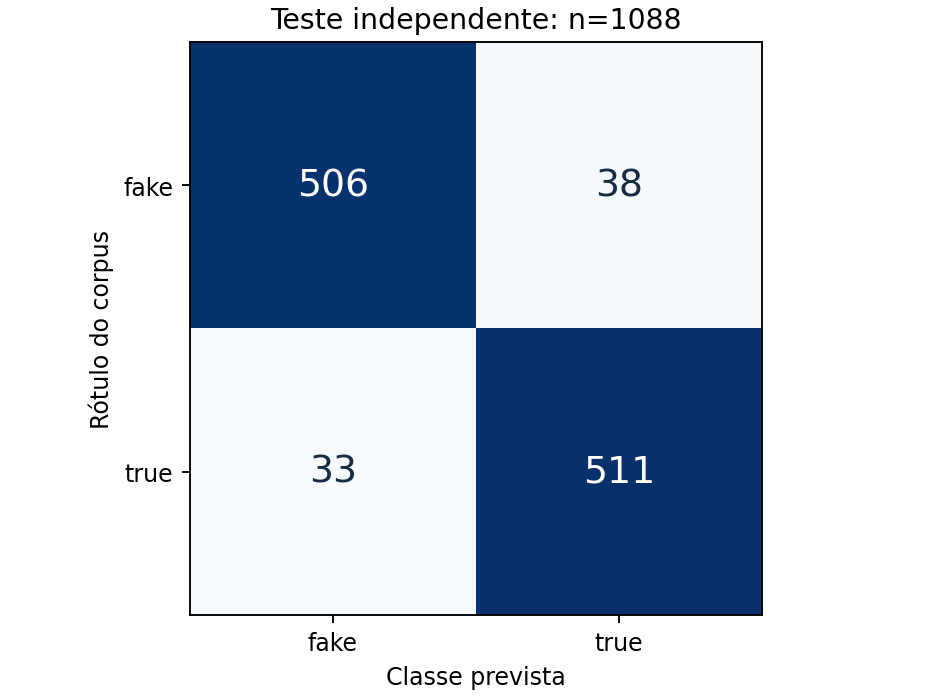

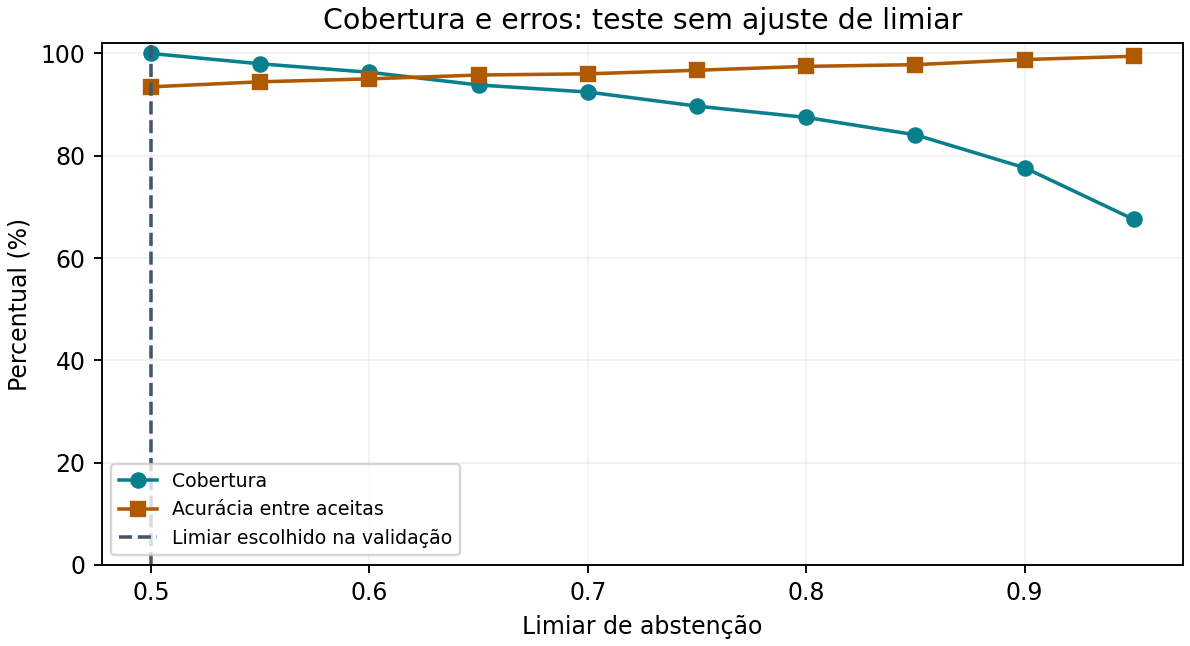

In [16]:
from IPython.display import display, Image
for name in ["confusao.png", "abstencao.png"]:
    display(Image(filename=str(ROOT / "figures" / name)))

## 4. Comparação com o classificador do projeto
O artefato anterior foi preservado para auditoria. Também retreinamos sua abordagem na mesma partição de treino do novo modelo. A comparação entre os dois modelos retreinados usa o mesmo teste. A avaliação do artefato original mede mudança de distribuição, pois ele foi construído com outro corpus.

A cópia de referência estabiliza a ordem do vocabulário nos empates. As demais equações são as do modelo anterior. Isso não modifica a aplicação.

In [17]:
sys.path.insert(0, str(ROOT / "source/legacy"))
from ml.classifier.model import ClaimClassifier
old = ClaimClassifier.load(str(ROOT / "models/modelo_anterior.json"))
reference = ClaimClassifier(alpha=0.5, acceptance_threshold=0.6)
reference.train([r["text"] for r in partitions["train"]], [r["label"] for r in partitions["train"]])
reference.save(str(ROOT / "models/baseline_legado_retreinado.json"))
y_test = [int(r["label"] == "true") for r in partitions["test"]]
comparison = {}
for name, model in [("original_model_on_real_test", old), ("legacy_retrained_same_partition", reference)]:
    probabilities = [model.predict_proba(r["text"])["true"] for r in partitions["test"]]
    comparison[name] = evaluate(y_test, probabilities, threshold=0.6)
    print(name, {k: comparison[name][k] for k in ["accuracy", "macro_f1", "coverage", "accepted_accuracy"]})
# Confere os números publicados na avaliação anterior deste pacote.
recorded = json.loads((ROOT / "results/legacy_comparison.json").read_text())
for name, result in comparison.items():
    assert abs(result["accuracy"] - recorded[name]["accuracy"]) < 1e-12
    assert abs(result["macro_f1"] - recorded[name]["macro_f1"]) < 1e-12

original_model_on_real_test {'accuracy': 0.5174632352941176, 'macro_f1': 0.4986056285731591, 'coverage': 0.6038602941176471, 'accepted_accuracy': 0.5053272450532724}
legacy_retrained_same_partition {'accuracy': 0.859375, 'macro_f1': 0.8590891891685988, 'coverage': 0.8602941176470589, 'accepted_accuracy': 0.9081196581196581}


## 5. Carregar o modelo salvo e executar inferência
O arquivo contém vetorizador, estimador, calibrador e limiar. Este exemplo utiliza apenas frases de demonstração não rotuladas: elas **não** integram o teste e não são usadas como prova de acurácia.

O resultado descreve similaridade linguística com as classes do corpus. `abstain` indica insuficiência de vocabulário ou confiança; não significa que uma fonte comprovou ou refutou a alegação.

In [18]:
with (ROOT / "models/modelo_treinado.pkl").open("rb") as file:
    restored = pickle.load(file)
examples = [
    "O ministério divulgou os dados oficiais do relatório sobre a economia brasileira.",
    "URGENTE! Compartilhe agora esta notícia antes que apaguem todas as provas!",
    "xqzv ttrn wpxk lzzq vvvx rrqq",
]
outputs = predict_bundle(restored, examples)
for row in outputs: print(json.dumps(row, ensure_ascii=False))
assert outputs[-1]["label"] == "abstain"
assert outputs[-1]["abstention_reason"] == "outside_vocabulary"
assert predict_bundle(restored, [partitions["test"][0]["text"]]) == predict_bundle(bundle, [partitions["test"][0]["text"]])

{"text": "O ministério divulgou os dados oficiais do relatório sobre a economia brasileira.", "predicted_class": "true", "label": "true", "probability_true": 0.9710766174194235, "confidence": 0.9710766174194235, "lexical_coverage": 0.6842105263157895, "abstention_reason": null}
{"text": "URGENTE! Compartilhe agora esta notícia antes que apaguem todas as provas!", "predicted_class": "fake", "label": "fake", "probability_true": 0.025370751855946585, "confidence": 0.9746292481440534, "lexical_coverage": 0.6190476190476191, "abstention_reason": null}
{"text": "xqzv ttrn wpxk lzzq vvvx rrqq", "predicted_class": "fake", "label": "abstain", "probability_true": 0.4538161184507171, "confidence": 0.5461838815492829, "lexical_coverage": 0.0, "abstention_reason": "outside_vocabulary"}


## 6. Diagnóstico do estado inconclusivo e limites da entrega
O classificador do projeto só acrescenta diagnóstico linguístico quando faltam evidências. Ele não altera `insufficient_evidence` para `supported` ou `contradicted` pela probabilidade do modelo. Isso é correto: vocabulário não comprova fatos.

O diagnóstico abaixo foi coletado neste computador. Não foi possível confirmar a configuração online nem o caso específico observado pelo usuário. A avaliação de retrieval/stance permanece sem rótulos humanos; nenhum F1 de checagem de vídeos é apresentado como validado.

In [19]:
diagnostic = json.loads((ROOT / "results/diagnostico.json").read_text())
print(json.dumps(diagnostic, indent=2, ensure_ascii=False))
print("Registro de execução: todos os asserts de partição, recarga e fora do vocabulário passaram.")

{
  "original_training_samples": 139,
  "curated_examples": 104,
  "original_classes": {
    "true": 69,
    "fake": 70
  },
  "local_configuration": {
    "provider": "mock",
    "configured_ollama_model": "qwen2.5:3b",
    "available_ollama_models": [
      "qwen3.5:9b"
    ],
    "configured_model_probe": {
      "http_status": 404,
      "error": "model 'qwen2.5:3b' not found"
    },
    "external_factcheck_key_configured": false,
    "evidence_index_exists": false
  },
  "human_annotated_pairs": 0,
  "application_revision": "0ffe395",
  "scope": "Diagnóstico local. Não confirma a configuração do serviço online."
}
Registro de execução: todos os asserts de partição, recarga e fora do vocabulário passaram.


## 7. Análise, desafios e lições
- Aumentar e verificar a procedência dos dados foi mais útil que apenas reduzir o limiar.
- Houve deduplicação, união de pares temáticos, separação de calibração e avaliação sem ajuste no teste.
- O vocabulário lexical captura padrões de fonte e estilo; pode falhar em notícias novas, paráfrases, ironia e negação. Não é um modelo de relação claim-evidence.
- A queda de desempenho em textos de 40 palavras evidencia mudança de distribuição; o rótulo usado nesse teste de estresse ainda é o da notícia inteira, não um rótulo humano da fala.
- Acurácia por classe, calibração e erro seletivo são necessários para entender a abstenção. Zero aceitas não equivale a precisão perfeita.
- O corpus é histórico e não valida generalização para vídeos atuais. Duplicatas semânticas não exatas ainda podem existir.
- A revisão não fez fine-tuning de Qwen, não publicou um produto e não substituiu o modelo da aplicação.

Referências: [corpus oficial Fake.br](https://github.com/roneysco/Fake.br-Corpus), [calibração scikit-learn](https://scikit-learn.org/stable/modules/calibration.html). A licença de redistribuição integral dos artigos não estava explícita no snapshot; o pacote fornece o procedimento de download, sem republicar textos completos.